In [5]:
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

<xarray.DataArray 'olr' ()> Size: 8B
array(523.14025485)
Coordinates:
    time       datetime64[ns] 8B 1979-04-30
    dayofyear  int64 8B ...

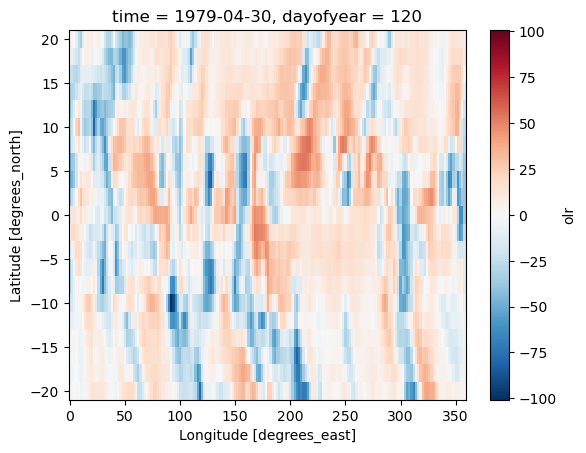

In [18]:
fn = '/pscratch/sd/l/linyaoly/MJO_ML_2024_redo/data/fltano120/olr.fltano120.noaa.2x2.1979to2022based1979to2001.nc'

ds = xr.open_dataset(fn)
ds['olr'][0].sel(lat=slice(20, -20)).plot()
olr = ds['olr'][0].sel(lat=slice(20, -20))
np.mean(olr**2)

In [19]:
ds = xr.open_dataset('/pscratch/sd/l/linyaoly/MJO_ML_2024_redo/data/rescaled_m10resi_wnx9resi/olr.fltano120.1978to2025based1979to2001.nc')


<xarray.DataArray 'olr' ()> Size: 8B
array(523.14025485)
Coordinates:
    time     datetime64[ns] 8B 1979-04-30

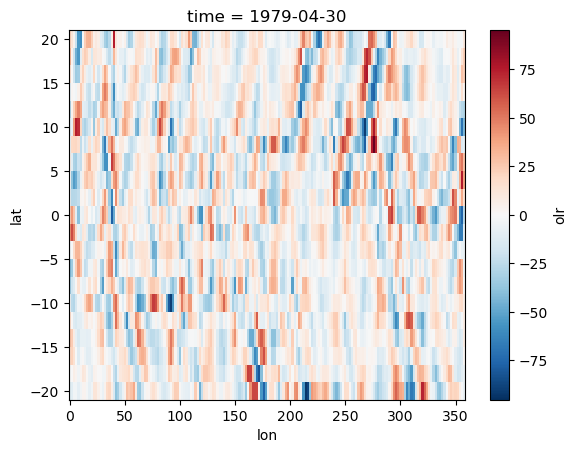

In [20]:
ds['olr'][0].plot()
olr = ds['olr'][0]
np.mean(olr**2)

# LL

In [9]:
rescale_input('olr', lat_range=[20, -20], c=51, m=10, mflg='all', wnx=9, wnxflg='all')

Filtered data saved to /pscratch/sd/l/linyaoly/MJO_ML_2024_redo/data/rescaled_m10all_wnx9all/olr.fltano120.1978to2025based1979to2001.nc


In [8]:
import sys
import numpy as np 
import xarray as xr 
import os
import math
import matplotlib.pyplot as plt
from scipy import special

def rescale_input(vn, lat_range=[20, -20], c=51, m=10, mflg='all', wnx=9, wnxflg='all'):
    """
    Read in vn data and filter it by projecting along the meridional direction using Hermite functions
    and filtering zonal waves via FFT. If a precomputed file exists, load and return the filtered data.
    Otherwise, compute the projection, store the filtered data into a netCDF file, and return it as a DataArray.

    Parameters:
      vn        : variable name (e.g. 'olr')
      time_range: [start_time, end_time] for selecting the time slice
      lat_range : [max_lat, min_lat] for the final output (applied at the end)
      dataflg   : flag to choose the input file type
      c         : parameter for the meridional projection (controls horizontal scale)
      m         : wave truncation (number of meridional modes)
      mflg      : flag for selecting which meridional modes to use 
                  ('off' to skip projection)
      wnx       : zonal wave number truncation (inclusive)
      wnxflg    : flag for selecting which zonal waves to retain 
                  ('off' to skip FFT filtering)
      pic_save  : if provided (directory path), a figure of the first time step is saved.
      
    Returns:
      An xarray DataArray of shape (time, selected lat, lon) with the filtered data.
    """
    # Set directory to store the output file
    out_dir = f'/pscratch/sd/l/linyaoly/MJO_ML_2024_redo/data/rescaled_m{m}{mflg}_wnx{wnx}{wnxflg}'
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)
        
    # Create a unique filename based on input parameters
    fname = os.path.join(out_dir, f'{vn}.fltano120.1978to2025based1979to2001.nc')
    
    # If the file exists, load and return the DataArray
    if os.path.exists(fname):
        print(f"Loading cached filtered data from {fname}")

    # -------- Choose the input file based on vn and dataflg --------

    if vn == 'olr':
        fn = f'/pscratch/sd/l/linyaoly/MJO_ML_2024_redo/data/fltano120/olr.fltano120.noaa.2x2.1979to2022based1979to2001.nc'
    else:
        fn = f'/pscratch/sd/l/linyaoly/MJO_ML_2024_redo/data/fltano120/{vn}.fltano120.1978to2025based1979to2001.nc'
    
    ds = xr.open_dataset(fn)
    # Select the desired time slice (keep full latitude range for filtering)
    ds1 = ds.fillna(0)
    lat = ds1['lat']
    lon = ds1['lon'].values
    time_arr = ds1['time'].values

    # Get the variable data as a NumPy array with shape (time, lat, lon)
    olr = ds1[vn].values  

    # -------- Meridional Filtering (Projection) --------
    if mflg == 'off':
        olr_re = np.copy(olr)
    else:
        beta = 2.28e-11  # variation of coriolis parameter with latitude
        L = np.sqrt(c / beta)  # horizontal scale (m)
        # Create a dimensionless coordinate y (using latitude in degrees)
        y = lat.values * 110e3 / L  
        
        phi = []  # list to store meridional basis functions
        
        # Determine which meridional modes to include
        if mflg=='all':
            m_list = np.arange(m)
        elif mflg=='resi':
            m_list = np.arange(m)
        else:
            print('wrong m flag!')
            exit()
            
        for i in m_list:
            # Compute Hermite polynomial of degree i evaluated at y
            p = special.hermite(i)
            Hm = p(y)
            # Normalize the Hermite function
            phim = np.exp(- y**2 / 2) * Hm / np.sqrt((2**i) * np.sqrt(np.pi) * math.factorial(i))
            # Reshape to (1, lat, 1) for broadcasting over time and longitude
            phi.append(np.reshape(phim, (1, len(y), 1)))
        
        # Compute projection coefficients by integrating along latitude (axis=1)
        olrm = []
        # Assume lat is regularly spaced; compute dy in dimensionless units
        dy = (lat.values[0] - lat.values[1]) * 110e3 / L  
        for i in range(len(m_list)):
            um = np.sum(olr * phi[i] * dy, axis=1, keepdims=True)  # shape: (time, 1, lon)
            olrm.append(um)
        
        # Reconstruct the field from the selected modes
        olr_re = np.zeros(np.shape(olr))
        for i in range(len(m_list)):
            olr_re += olrm[i] * phi[i]
        
        # If mflg is 'resi', remove the reconstructed part from the original field
        if mflg == 'resi':
            olr_re = olr - olr_re

    # -------- Zonal Filtering (FFT) --------
    if wnxflg == 'off':
        olr_re_fft = np.copy(olr_re)
    else:
        # FFT along the longitude axis (axis=2)
        coef_fft = np.fft.rfft(olr_re, axis=2)
        # Apply filtering based on wnxflg flag
        if wnxflg=='all':
            coef_fft[:, :, wnx+1:] = 0.0 
        elif wnxflg=='resi':
            coef_fft[:, :, :wnx+1] = 0.0
        else:
            print('wrong wnx flag!')
            exit()
        # Inverse FFT to reconstruct the filtered field along longitude
        olr_re_fft = np.fft.irfft(coef_fft, n=olr_re.shape[2], axis=2)
    
    # -------- Select the Final Latitude Range --------
    lat_ind = np.where((lat.values >= lat_range[1]) & (lat.values <= lat_range[0]))[0]
    olr_filtered = olr_re_fft[:, lat_ind, :]

    raw_power = np.mean(olr[:, lat_ind, :]**2, axis=(1,2))
    filtered_power = np.mean(olr_filtered**2, axis=(1,2))
    factor = np.sqrt(raw_power / filtered_power)
    # -------- Save the filtered data to a netCDF file --------
    ds_out = xr.Dataset(
        {
            vn: (("time", "lat", "lon"), olr_filtered * factor[:, None, None])
        },
        coords={
            "time": time_arr,
            "lat": lat.values[lat_ind],
            "lon": lon
        }
    )

    ds_out.to_netcdf(fname, mode='w')
    print(f"Filtered data saved to {fname}")
    
